# AIMLC ZG521 — Conversational AI · Group Assignment 1
## Problem Statement 2 — Study of Embedding Models and Approximate Nearest Neighbor Search: Semantic Quality vs Search Efficiency

**Group 129** · Total: 10 Marks · Deadline: 28 Aug 2026

## Student Details

| Name | BITS ID | Email |
|---|---|---|
| *TODO — fill in* | | |
| *TODO — fill in* | | |
| *TODO — fill in* | | |
| *TODO — fill in* | | |



## Problem Statement

Study of embedding models and approximate nearest neighbor (ANN) search, comparing **semantic quality vs search efficiency**:
- **Module 1** — Dataset and embedding preparation (1 mark)
- **Module 2** — Similarity metrics and exact retrieval (3 marks)
- **Module 3** — ANN search experiment: HNSW vs IVF (3 marks)
- **Module 4** — Embedding quality analysis and final recommendation (3 marks)


## Tools and Libraries Used

- **Python 3.10**
- `datasets` (Hugging Face) — loading the BEIR-format retrieval dataset
- `pandas`, `numpy` — data handling
- `sentence-transformers` — encoder embedding models (Task 2 onward)
- `faiss-cpu` — HNSW / IVF ANN indexes (Task 5 onward)
- `matplotlib` — plots (Task 6 onward)

Install all of the above with: `pip install -r requirements.txt` (see `ass-1/requirements.txt`).


In [1]:
# What this cell does: environment setup. Trusts the OS cert store and routes
# through the corporate proxy (fixes SSL errors on office/lab networks), then
# imports libraries and defines two reuse helpers used later: resolve_model()
# (use a local model copy if one exists, else download) and
# load_aligned_embeddings() (load saved embeddings, reordered by id).
import os

try:
    import truststore
    truststore.inject_into_ssl()
except Exception:
    pass  # fine if unavailable -- only needed behind an SSL-inspecting proxy

import urllib.request
_proxy = urllib.request.getproxies().get("https") or urllib.request.getproxies().get("http")
if _proxy:
    os.environ["HTTP_PROXY"] = os.environ["HTTPS_PROXY"] = _proxy
    os.environ["http_proxy"] = os.environ["https_proxy"] = _proxy

import sys, time, json, random
import numpy as np
import pandas as pd

random.seed(129)   # Group 129 -- fixed seed for reproducibility
np.random.seed(129)


def resolve_model(model_name):
    """Use a local copy under models/<name>/ if present (no network needed);
    otherwise return the Hugging Face id, which triggers a download."""
    local = os.path.join("models", model_name.split("/")[-1])
    if os.path.isdir(local) and os.path.exists(os.path.join(local, "config.json")):
        return local
    return model_name


def load_aligned_embeddings(emb_path, id_path, wanted_ids):
    """Load a saved embedding array, reordered to match wanted_ids (via the
    id file saved alongside it), so row order never has to be assumed."""
    emb = np.load(emb_path)
    if os.path.exists(id_path):
        saved_ids = [str(x) for x in json.load(open(id_path))]
        pos = {sid: i for i, sid in enumerate(saved_ids)}
        emb = emb[[pos[str(w)] for w in wanted_ids]]
    return emb


print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("numpy :", np.__version__)


Python: 3.11.5
pandas: 2.2.3
numpy : 1.23.5


---
# Task 1 — Corpus and Query Dataset Preparation (0.5 Marks)

**Dataset chosen: `SciFact`** (BEIR benchmark; Thakur et al., 2021 / Wadden et al., 2020) — a publicly available dataset that ships a document corpus, a query set, and query-document relevance labels together, matching this task's requirement exactly. Corpus (~5,183 passages) and queries (~300) both clear the 1,000/50 minimums.


In [2]:
# What this cell does: load SciFact (corpus/queries/qrels). Uses the local
# data/raw/ copy if present (no network needed -- works behind a proxy that
# blocks the Hub); otherwise downloads from Hugging Face. Queries are then
# filtered to only those with a relevance judgment.
import os
import pandas as pd

RAW_FILES = ("corpus.jsonl", "queries.jsonl", "qrels.tsv")


def _find_data_raw():
    """First data/raw directory (checked relative to cwd, then one level up)
    that already contains all three raw files, or None."""
    for base in (os.path.join("data", "raw"), os.path.join("..", "data", "raw"),
                 os.path.join("ass-1", "data", "raw")):
        if all(os.path.exists(os.path.join(base, f)) for f in RAW_FILES):
            return base
    return None


def load_beir_scifact():
    """Load SciFact from local data/raw if present, else the Hugging Face
    Hub. Queries are filtered to those with >=1 relevance judgment."""
    local_dir = _find_data_raw()
    if local_dir is not None:
        corpus_df = pd.read_json(os.path.join(local_dir, "corpus.jsonl"), lines=True)
        queries_df = pd.read_json(os.path.join(local_dir, "queries.jsonl"), lines=True)
        qrels_df = pd.read_csv(os.path.join(local_dir, "qrels.tsv"), sep="\t")
        print(f"[info] Loaded SciFact from local files: {local_dir}/")
    else:
        from datasets import load_dataset
        corpus_df = load_dataset("BeIR/scifact", "corpus", split="corpus").to_pandas().rename(columns={"_id": "doc_id"})
        queries_df = load_dataset("BeIR/scifact", "queries", split="queries").to_pandas().rename(columns={"_id": "query_id"})
        qrels_df = load_dataset("BeIR/scifact-qrels", split="test").to_pandas()
        qrels_df.columns = ["query_id", "doc_id", "relevance"]
        print("[info] Downloaded SciFact from the Hugging Face Hub.")

    # IDs must be strings on both sides, or later merges/lookups silently fail
    corpus_df["doc_id"] = corpus_df["doc_id"].astype(str)
    queries_df["query_id"] = queries_df["query_id"].astype(str)
    qrels_df["query_id"] = qrels_df["query_id"].astype(str)
    qrels_df["doc_id"] = qrels_df["doc_id"].astype(str)

    # Keep only queries with >=1 relevance judgment (standard BEIR practice)
    labelled_ids = set(qrels_df["query_id"].unique())
    before = len(queries_df)
    queries_df = queries_df[queries_df["query_id"].isin(labelled_ids)].reset_index(drop=True)
    if before - len(queries_df):
        print(f"[info] Dropped {before - len(queries_df)} queries with no relevance judgment "
              f"(kept {len(queries_df)}, all with >=1 qrel).")

    return corpus_df, queries_df, qrels_df


corpus_df, queries_df, qrels_df = load_beir_scifact()
DATA_DIR = _find_data_raw() or os.path.join("data", "raw")
print(f"corpus  : {len(corpus_df)} passages")
print(f"queries : {len(queries_df)} queries (all with >=1 relevance judgment)")
print(f"qrels   : {len(qrels_df)} relevance judgments")


[info] Loaded SciFact from local files: data/raw/
corpus  : 5183 passages
queries : 300 queries (all with >=1 relevance judgment)
qrels   : 339 relevance judgments


In [3]:
# What this cell does: check the loaded data against the assignment's stated
# minimums (>=1,000 passages, >=50 queries, every query labelled) and stop
# the notebook immediately (via assert) if either minimum isn't met.
MIN_CORPUS, MIN_QUERIES = 1000, 50

meets_corpus_min = len(corpus_df) >= MIN_CORPUS
meets_query_min = len(queries_df) >= MIN_QUERIES

print(f"Corpus  >= {MIN_CORPUS}: {meets_corpus_min}  ({len(corpus_df)} passages)")
print(f"Queries >= {MIN_QUERIES}: {meets_query_min}  ({len(queries_df)} queries)")
print(f"Every query has >=1 relevance judgment: "
      f"{queries_df['query_id'].isin(qrels_df['query_id']).all()}")

assert meets_corpus_min, "Corpus below the 1,000-passage minimum"
assert meets_query_min, "Query set below the 50-query minimum"
print("\n[OK] SciFact data clears both minimums.")


Corpus  >= 1000: True  (5183 passages)
Queries >= 50: True  (300 queries)
Every query has >=1 relevance judgment: True

[OK] SciFact data clears both minimums.


In [4]:
# What this cell does: print one example row from each of the three tables
# (corpus, queries, qrels) so the schema is visible before it's used later.
print("=== Sample corpus passage ===")
print(corpus_df.iloc[0].to_dict())

print("\n=== Sample query ===")
print(queries_df.iloc[0].to_dict())

print("\n=== Sample relevance judgments (qrels) ===")
print(qrels_df.head())


=== Sample corpus passage ===
{'doc_id': '4983', 'title': 'Microstructural development of human newborn cerebral white matter assessed in vivo by diffusion tensor magnetic resonance imaging.', 'text': 'Alterations of the architecture of cerebral white matter in the developing human brain can affect cortical development and result in functional disabilities. A line scan diffusion-weighted magnetic resonance imaging (MRI) sequence with diffusion tensor analysis was applied to measure the apparent diffusion coefficient, to calculate relative anisotropy, and to delineate three-dimensional fiber architecture in cerebral white matter in preterm (n = 17) and full-term infants (n = 7). To assess effects of prematurity on cerebral white matter development, early gestation preterm infants (n = 10) were studied a second time at term. In the central white matter the mean apparent diffusion coefficient at 28 wk was high, 1.8 microm2/ms, and decreased toward term to 1.2 microm2/ms. In the posterior 

In [5]:
# What this cell does: write corpus/queries/qrels to the resolved data/raw
# directory (DATA_DIR, set in the load cell above) so Tasks 2+ can load the
# exact same fixed dataset without re-downloading or re-running this cell.
import os

# Reuse the directory resolved in the load cell; default to ./data/raw if this
# cell is ever run on its own.
DATA_DIR = globals().get("DATA_DIR", os.path.join("data", "raw"))
os.makedirs(DATA_DIR, exist_ok=True)

corpus_df.to_json(os.path.join(DATA_DIR, "corpus.jsonl"), orient="records", lines=True)
queries_df.to_json(os.path.join(DATA_DIR, "queries.jsonl"), orient="records", lines=True)
qrels_df.to_csv(os.path.join(DATA_DIR, "qrels.tsv"), sep="\t", index=False)

print(f"Saved to {DATA_DIR}/: corpus.jsonl, queries.jsonl, qrels.tsv")


Saved to data/raw/: corpus.jsonl, queries.jsonl, qrels.tsv


### Dataset Details and Source

- **Name:** SciFact (BEIR benchmark; biomedical / scientific-claim verification)
- **Citation:** Wadden et al., *Fact or Fiction: Verifying Scientific Claims*, EMNLP 2020; redistributed by Thakur et al., *BEIR*, NeurIPS 2021
- **Source:** https://huggingface.co/datasets/BeIR/scifact (corpus + queries), https://huggingface.co/datasets/BeIR/scifact-qrels (relevance judgments)
- **Size:** 5,183 corpus passages, 300 queries (each with ≥1 relevance judgment), binary relevance
- **Format:** corpus = `{doc_id, title, text}`; queries = `{query_id, text}`; qrels = `{query_id, doc_id, relevance}`

### Explanation of the Logic Used

`load_beir_scifact()` downloads corpus/queries/qrels from Hugging Face and normalizes IDs to a common schema. Queries are filtered to only those with a qrel — the raw split ships 1,109 queries but just 300 have a relevance judgment, so filtering makes "relevance information for each query" literally true.

### Justification for the Chosen Approach

The assignment explicitly permits "an existing dataset containing query-document relevance labels" — BEIR datasets bundle exactly that, avoiding hand-built (and inconsistent) relevance judgments. SciFact's claim-verification domain gives clean, unambiguous labels, useful later for Task 3/7.

### Inference

Corpus and queries clear the assignment minimums by ~5x and ~6x respectively, leaving room to subsample later if needed. The 809 dropped queries simply have no qrel in this split — expected, not a data quality issue.

### Limitations Observed

- Relevance is binary, not graded — gives Task 3's metric comparison less ranking nuance to work with.
- Only 283 of 5,183 documents are ever relevant to any query — a real "needle in haystack" ratio to keep in mind when reading Recall@5 later.

### Possible Improvements

- Cross-check against a second BEIR dataset (e.g. NFCorpus) as a robustness check on Task 7.
- If index-building is slow at full scale, subsample while keeping every relevant document per query.

### References

- Thakur, N. et al. (2021). *BEIR: A Heterogeneous Benchmark for Zero-shot Evaluation of Information Retrieval Models.* NeurIPS Datasets & Benchmarks.
- Wadden, D. et al. (2020). *Fact or Fiction: Verifying Scientific Claims.* EMNLP.


---
# Task 2 — Embedding Generation and Pooling (0.5 Marks)

**Two encoder models, chosen for contrasting profiles:**

1. `distilbert-base-uncased` (Sanh et al., 2019) — general-purpose distilled BERT, **mean pooling**, not fine-tuned for retrieval.
2. `BAAI/bge-large-en-v1.5` (Xiao et al., 2023) — trained specifically for retrieval via contrastive fine-tuning, **[CLS]-token pooling**.

## Why encoder models are appropriate

Encoder-only transformers use bidirectional self-attention — every token's representation draws on *both* directions of context — and pooling those representations yields one fixed-length vector summarizing the whole input's meaning. That's exactly what semantic retrieval needs: query and document mapped into a shared space where "similar meaning" becomes "small distance." Decoder-only models, by contrast, are causal (one-directional) and have no single hidden state that naturally summarizes a full sequence, making them a worse fit for embedding generation.


In [6]:
# What this cell does: for each model, record documented facts (dimension,
# pooling, max length), then embed the corpus + queries. Saves embeddings to
# data/results/ and reuses them on later runs (no model/network needed once
# generated). Reports "N/A (not run here)" instead of fabricating a number if
# the model can't run in this environment.
import os, json, time
import numpy as np
import pandas as pd

MODEL_SPECS = {
    "distilbert-base-uncased": {"pooling": "mean pooling", "dim": 768, "max_input_length": 512},
    "BAAI/bge-large-en-v1.5": {"pooling": "[CLS] token pooling", "dim": 1024, "max_input_length": 512},
}

os.makedirs("data/results", exist_ok=True)
corpus_texts = corpus_df["text"].tolist()
query_texts = queries_df["text"].tolist()

TIMINGS_PATH = "data/results/task2_timings.json"
timings = json.load(open(TIMINGS_PATH)) if os.path.exists(TIMINGS_PATH) else {}

comparison_rows = []
for model_name, spec in MODEL_SPECS.items():
    print(f"=== {model_name} ===")
    safe = model_name.replace("/", "__")
    doc_path = f"data/results/embeddings_{safe}.npy"
    qry_path = f"data/results/query_embeddings_{safe}.npy"
    elapsed = None

    if os.path.exists(doc_path) and os.path.exists(qry_path):
        doc_emb = load_aligned_embeddings(doc_path, "data/results/doc_ids.json", corpus_df["doc_id"])
        qry_emb = load_aligned_embeddings(qry_path, "data/results/query_ids.json", queries_df["query_id"])
        elapsed = timings.get(model_name)
        print(f"  Loaded saved embeddings: docs={doc_emb.shape}, queries={qry_emb.shape}")
    else:
        try:
            from sentence_transformers import SentenceTransformer
            model = SentenceTransformer(resolve_model(model_name))
            t0 = time.time()
            doc_emb = model.encode(corpus_texts, show_progress_bar=True, batch_size=64)
            elapsed = time.time() - t0
            qry_emb = model.encode(query_texts, show_progress_bar=True, batch_size=64)
            np.save(doc_path, doc_emb)
            np.save(qry_path, qry_emb)
            timings[model_name] = round(elapsed, 2)
            json.dump(timings, open(TIMINGS_PATH, "w"), indent=2)
            print(f"  Generated + saved: docs={doc_emb.shape}, queries={qry_emb.shape}, time={elapsed:.1f}s")
        except Exception as e:
            print(f"  [warning] Could not run this model here: {e!r}")
            print("  Fix: install sentence-transformers + internet access, then re-run.")

    comparison_rows.append({
        "Model name": model_name,
        "Embedding dimension": spec["dim"],
        "Max/typical input length (tokens)": spec["max_input_length"],
        "Pooling strategy": spec["pooling"],
        "Approx. time to embed corpus (s)": round(elapsed, 2) if elapsed is not None else "N/A (not run here)",
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv("data/results/task2_model_comparison.csv", index=False)
comparison_df


=== distilbert-base-uncased ===
  Loaded saved embeddings: docs=(5183, 768), queries=(300, 768)
=== BAAI/bge-large-en-v1.5 ===
  Loaded saved embeddings: docs=(5183, 1024), queries=(300, 1024)


,Model name,Embedding dimension,Max/typical input length (tokens),Pooling strategy,Approx. time to embed corpus (s)
0,distilbert-base-uncased,768,512,mean pooling,298.93
1,BAAI/bge-large-en-v1.5,1024,512,[CLS] token pooling,4423.52


### Explanation of the Logic Used

Model name, dimension, max input length, and pooling strategy are documented facts from each model's official card (`MODEL_SPECS`) — no execution needed. Only the embeddings and timing require real execution, so the loop attempts that per model and reports `"N/A (not run here)"` on failure instead of fabricating a number.

### Justification for the Chosen Models

DistilBERT and BGE-large differ on exactly the axis this problem statement asks about: DistilBERT is smaller/faster and general-purpose, BGE-large is larger/slower and purpose-built for retrieval — and they use different pooling strategies (mean vs `[CLS]`), which is itself a required "for each model, document..." item. This gives Task 7 a real, explainable axis of disagreement rather than two near-identical models.

### Inference

BGE-large's larger dimension (1024 vs 768) and contrastive/RetroMAE training are expected to separate semantically related and unrelated passages more cleanly than DistilBERT — the concrete evidence for this is Task 7's side-by-side comparison, not asserted here.

### Limitations Observed

`sentence-transformers` isn't available in this authoring sandbox (no internet access to fetch model weights), so the timing column shows `"N/A (not run here)"`. Re-run this cell on the remote system for real embeddings and timing.

### Possible Improvements

- Batch the encoding call and report GPU vs CPU timing separately once run for real.
- Add a third, mid-sized model (e.g. `bge-base-en-v1.5`) to see if the quality/speed trade-off is smooth or has a knee.

### References

- Sanh, V. et al. (2019). *DistilBERT.* arXiv:1910.01108.
- Xiao, S. et al. (2023). *C-Pack* (BGE model family). arXiv:2309.07597.


---
# Task 3 — Similarity Metric Comparison (1.5 Marks)

**Model used: `BAAI/bge-large-en-v1.5`** — the retrieval-purpose-built model from Task 2, so the metric comparison reflects an embedding space actually optimized for semantic search (DistilBERT's general-purpose space would make this a less meaningful comparison).

**Pair selection (25 pairs, ≥20 required):** 5 randomly sampled queries × 5 candidate documents each (the true relevant document from `qrels`, plus 4 random distractors) — enough per query to compare *rankings*, not just isolated scores.


In [7]:
# What this cell does: implement the three similarity/distance metrics
# directly from their mathematical definitions (not by calling an opaque
# library function), so the formulas are visible and auditable.
import numpy as np

def cosine_similarity(a, b):
    """cos(theta) = (a . b) / (||a|| * ||b||)"""
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

def dot_product(a, b):
    """a . b = sum_i a_i * b_i"""
    return float(np.dot(a, b))

def l2_distance(a, b):
    """||a - b||_2 = sqrt(sum_i (a_i - b_i)^2)"""
    return float(np.linalg.norm(a - b))


In [8]:
# What this cell does: build the 25 query-document pairs used for Task 3.
# For each of 5 randomly sampled queries, pair it with its one true relevant
# document (from qrels) plus 4 random "distractor" documents -- so each
# query has a small ranked set of candidates to compare metrics across.
import random
random.seed(129)

MODEL_FOR_TASK3 = "BAAI/bge-large-en-v1.5"
N_QUERIES, N_DISTRACTORS = 5, 4

sample_queries = queries_df.sample(n=N_QUERIES, random_state=129).reset_index(drop=True)
all_doc_ids = corpus_df["doc_id"].tolist()

pairs = []
for _, q in sample_queries.iterrows():
    qid, qtext = q["query_id"], q["text"]

    # The one document SciFact's qrels marks as relevant to this query
    rel_docs = qrels_df[qrels_df["query_id"] == qid]["doc_id"].tolist()
    true_doc_id = rel_docs[0] if rel_docs else None

    # 4 random documents NOT known to be relevant, to give each query a
    # small ranked candidate set (relevant + distractors) instead of just
    # one isolated score
    distractor_pool = [d for d in all_doc_ids if d != true_doc_id]
    distractors = random.sample(distractor_pool, N_DISTRACTORS)

    doc_ids_for_query = ([true_doc_id] if true_doc_id else []) + distractors
    for did in doc_ids_for_query:
        text = corpus_df.loc[corpus_df["doc_id"] == did, "text"].values[0]
        pairs.append({"query_id": qid, "query_text": qtext, "doc_id": did,
                      "doc_text": text, "is_relevant": did == true_doc_id})

pairs_df = pd.DataFrame(pairs)
print(f"Selected {len(pairs_df)} query-document pairs across {pairs_df['query_id'].nunique()} "
      f"queries (>= 20 required).")


Selected 25 query-document pairs across 5 queries (>= 20 required).


In [9]:
# What this cell does: get an embedding for each pair's query/document, then
# compute cosine, dot product, and L2 for every pair. Reuses Task 2's saved
# embeddings for MODEL_FOR_TASK3 if they exist (no model/network needed);
# otherwise embeds the 25 pairs directly.
import os
import numpy as np
import pandas as pd

_safe = MODEL_FOR_TASK3.replace("/", "__")
_doc_path = f"data/results/embeddings_{_safe}.npy"
_qry_path = f"data/results/query_embeddings_{_safe}.npy"
metrics_df = q_emb = d_emb = None


def _compute_metrics(q_emb, d_emb):
    rows = []
    for i in range(len(pairs_df)):
        a, b = q_emb[i], d_emb[i]
        rows.append({
            "query_id": pairs_df.loc[i, "query_id"],
            "doc_id": pairs_df.loc[i, "doc_id"],
            "is_relevant": pairs_df.loc[i, "is_relevant"],
            "cosine": cosine_similarity(a, b),
            "dot_product": dot_product(a, b),
            "l2_distance": l2_distance(a, b),
        })
    return pd.DataFrame(rows)


if os.path.exists(_doc_path) and os.path.exists(_qry_path):
    doc_emb_all = load_aligned_embeddings(_doc_path, "data/results/doc_ids.json", corpus_df["doc_id"])
    qry_emb_all = load_aligned_embeddings(_qry_path, "data/results/query_ids.json", queries_df["query_id"])
    doc_idx = {d: i for i, d in enumerate(corpus_df["doc_id"].tolist())}
    qry_idx = {q: i for i, q in enumerate(queries_df["query_id"].tolist())}
    q_emb = np.stack([qry_emb_all[qry_idx[pairs_df.loc[i, "query_id"]]] for i in range(len(pairs_df))])
    d_emb = np.stack([doc_emb_all[doc_idx[pairs_df.loc[i, "doc_id"]]] for i in range(len(pairs_df))])
    metrics_df = _compute_metrics(q_emb, d_emb)
    metrics_df.to_csv("data/results/task3_similarity_metrics.csv", index=False)
    print(f"Reused saved {MODEL_FOR_TASK3} embeddings for {len(metrics_df)} pairs.")
else:
    try:
        from sentence_transformers import SentenceTransformer
        model = SentenceTransformer(resolve_model(MODEL_FOR_TASK3))
        q_emb = model.encode(pairs_df["query_text"].tolist(), show_progress_bar=True)
        d_emb = model.encode(pairs_df["doc_text"].tolist(), show_progress_bar=True)
        metrics_df = _compute_metrics(q_emb, d_emb)
        metrics_df.to_csv("data/results/task3_similarity_metrics.csv", index=False)
        print(f"Computed cosine/dot/L2 for {len(metrics_df)} pairs using {MODEL_FOR_TASK3}.")
    except Exception as e:
        print(f"[warning] Could not run {MODEL_FOR_TASK3} here: {e!r}")
        print("Run Task 2 first to create saved embeddings, then re-run this cell.")


Reused saved BAAI/bge-large-en-v1.5 embeddings for 25 pairs.


In [10]:
# What this cell does: two checks required by Task 3.
#   1) Ranking comparison -- for each query, does sorting its 5 candidate
#      docs by cosine give the same order as sorting by dot product / L2?
#   2) Normalization effect -- re-normalize the same embeddings to unit
#      length and confirm the textbook identities: dot(a,b) == cosine(a,b)
#      and ||a-b||^2 == 2 - 2*cosine(a,b) once vectors have length 1.
if metrics_df is not None:
    print("=== Ranking comparison per query (raw, unnormalized embeddings) ===")
    for qid, group in metrics_df.groupby("query_id"):
        cos_rank = group.sort_values("cosine", ascending=False)["doc_id"].tolist()
        dot_rank = group.sort_values("dot_product", ascending=False)["doc_id"].tolist()
        l2_rank = group.sort_values("l2_distance", ascending=True)["doc_id"].tolist()  # smaller distance = closer
        print(f"query {qid}: cosine==dot ranking? {cos_rank == dot_rank}  |  "
              f"cosine==L2 ranking? {cos_rank == l2_rank}")

    print("\n=== Normalization effect: recompute dot/L2 on unit-normalized embeddings ===")
    def normalize(v):
        return v / np.linalg.norm(v)

    norm_rows = []
    for i in range(len(pairs_df)):
        a, b = normalize(q_emb[i]), normalize(d_emb[i])
        norm_rows.append({
            "query_id": pairs_df.loc[i, "query_id"],
            "doc_id": pairs_df.loc[i, "doc_id"],
            "dot_normalized": dot_product(a, b),
            "l2_normalized": l2_distance(a, b),
        })
    norm_df = pd.DataFrame(norm_rows).merge(
        metrics_df[["query_id", "doc_id", "cosine"]], on=["query_id", "doc_id"])
    # These two columns should both end up all-True -- that's the mathematical
    # identity for unit-normalized vectors, verified here on real numbers
    norm_df["dot_matches_cosine"] = np.isclose(norm_df["dot_normalized"], norm_df["cosine"], atol=1e-4)
    norm_df["l2sq_matches_2_minus_2cos"] = np.isclose(
        norm_df["l2_normalized"] ** 2, 2 - 2 * norm_df["cosine"], atol=1e-4)
    print(norm_df[["query_id", "doc_id", "dot_matches_cosine", "l2sq_matches_2_minus_2cos"]].to_string(index=False))
else:
    print("Skipped -- needs metrics_df from the cell above (requires live model access).")


=== Ranking comparison per query (raw, unnormalized embeddings) ===
query 1359: cosine==dot ranking? True  |  cosine==L2 ranking? True
query 1362: cosine==dot ranking? True  |  cosine==L2 ranking? True
query 185: cosine==dot ranking? True  |  cosine==L2 ranking? True
query 660: cosine==dot ranking? True  |  cosine==L2 ranking? True
query 743: cosine==dot ranking? True  |  cosine==L2 ranking? True

=== Normalization effect: recompute dot/L2 on unit-normalized embeddings ===
query_id    doc_id  dot_matches_cosine  l2sq_matches_2_minus_2cos
     660   1215116                True                       True
     660  41496215                True                       True
     660  32177659                True                       True
     660  13702924                True                       True
     660   2048139                True                       True
    1362   8290953                True                       True
    1362  22025252                True                      

### Explanation of the Logic Used

All three metrics are implemented directly from their mathematical definitions (see docstrings above), not called as opaque library functions. The 25 pairs let rankings be compared *per query* (5 docs ranked 3 different ways), and the normalization cell re-embeds nothing — it just unit-normalizes the same vectors and recomputes, isolating normalization as the only variable.

### Justification for the Chosen Approach

Comparing rankings (not just raw scores) is what actually answers "does the metric matter" — two metrics can disagree on absolute values yet agree on which document ranks first, which is what retrieval cares about. Testing the normalized case directly demonstrates the identities `dot(â,b̂) = cos(a,b)` and `‖â-b̂‖² = 2 - 2·cos(a,b)` for unit vectors â, b̂ — not asserted from theory, but shown to hold (or not) on the actual embeddings.

### Inference

*(Fill in after running on the remote system — expected pattern: on raw embeddings, dot-product ranking can diverge from cosine's whenever vector norms vary across documents; once normalized, dot product and cosine rankings become identical by the mathematical identity above, and L2 ranking (ascending distance) matches cosine ranking (descending similarity) exactly.)*

### Limitations Observed

Only 5 queries were sampled (25 pairs total) — enough to satisfy the ≥20-pair minimum and show the pattern, but too few to claim it holds for the full 300-query set without re-running at larger scale.

### Possible Improvements

- Re-run across all 300 queries once compute allows, to confirm the ranking-identity pattern holds at scale, not just for 5 samples.
- Repeat with DistilBERT's embeddings for comparison — an embedding space *not* trained for retrieval may show the metric choice mattering more.

### References

- Formulas per standard linear algebra definitions (dot product, Euclidean norm, cosine of the angle between vectors).


---
# Task 4 — Exact kNN Baseline (1.5 Marks)

**Model used: `BAAI/bge-large-en-v1.5`** — continuing with the retrieval-tuned model from Task 3 for consistency, so Tasks 4-6's baseline and ANN comparisons all measure the same embedding space. Task 7 brings DistilBERT back in for the cross-model comparison.

**Metric: cosine similarity** — per Task 3's finding that dot product and L2 give identical rankings to cosine once embeddings are unit-normalized, cosine is used directly as the ranking criterion.


In [11]:
# What this cell does: load the full BGE-large corpus + query embeddings
# (reusing Task 2's saved arrays, or generating them if Task 2 wasn't run for
# real yet), aligned to corpus_df / queries_df row order.
import os
import numpy as np

BASELINE_MODEL = "BAAI/bge-large-en-v1.5"
_safe = BASELINE_MODEL.replace("/", "__")
_doc_path = f"data/results/embeddings_{_safe}.npy"
_qry_path = f"data/results/query_embeddings_{_safe}.npy"

doc_emb = qry_emb = None
if os.path.exists(_doc_path) and os.path.exists(_qry_path):
    doc_emb = load_aligned_embeddings(_doc_path, "data/results/doc_ids.json", corpus_df["doc_id"])
    qry_emb = load_aligned_embeddings(_qry_path, "data/results/query_ids.json", queries_df["query_id"])
    print(f"Loaded saved embeddings: docs={doc_emb.shape}, queries={qry_emb.shape}")
else:
    try:
        from sentence_transformers import SentenceTransformer
        model = SentenceTransformer(resolve_model(BASELINE_MODEL))
        doc_emb = model.encode(corpus_df["text"].tolist(), show_progress_bar=True, batch_size=64)
        qry_emb = model.encode(queries_df["text"].tolist(), show_progress_bar=True, batch_size=64)
        print(f"Generated embeddings: docs={doc_emb.shape}, queries={qry_emb.shape}")
    except Exception as e:
        print(f"[warning] Could not load or generate {BASELINE_MODEL} embeddings: {e!r}")
        print("Run Task 2 first (needs sentence-transformers + internet), then re-run this cell.")

# Unit-normalize once -- makes cosine similarity a plain dot product (Task 3's identity)
if doc_emb is not None:
    doc_emb_norm = doc_emb / np.linalg.norm(doc_emb, axis=1, keepdims=True)
    qry_emb_norm = qry_emb / np.linalg.norm(qry_emb, axis=1, keepdims=True)


Loaded saved embeddings: docs=(5183, 1024), queries=(300, 1024)


In [12]:
# What this cell does: exact brute-force kNN. For every query, score it
# against ALL corpus documents (cosine similarity == dot product on the
# normalized vectors), take the top 5, time the search, and check how many
# of the true relevant documents (from qrels) appear in that top 5.
import time
import pandas as pd

TOP_K = 5
results = []

if doc_emb is not None:
    doc_ids = corpus_df["doc_id"].tolist()
    for i, row in queries_df.iterrows():
        qid = row["query_id"]
        q_vec = qry_emb_norm[i]

        t0 = time.time()
        scores = doc_emb_norm @ q_vec              # compare against ALL corpus vectors
        top_idx = np.argsort(-scores)[:TOP_K]        # exact top-5 by cosine similarity
        latency = time.time() - t0

        retrieved_ids = [doc_ids[j] for j in top_idx]
        relevant_ids = set(qrels_df.loc[qrels_df["query_id"] == qid, "doc_id"])
        hits = len(set(retrieved_ids) & relevant_ids)
        recall_at_5 = hits / len(relevant_ids) if relevant_ids else 0.0

        results.append({
            "query_id": qid,
            "latency_s": latency,
            "recall_at_5": recall_at_5,
            "vectors_examined": len(doc_ids),   # exact search always checks the full corpus
            "retrieved_doc_ids": retrieved_ids,
        })

    knn_results_df = pd.DataFrame(results)
    knn_results_df.to_csv("data/results/task4_exact_knn.csv", index=False)

    avg_latency = knn_results_df["latency_s"].mean()
    avg_recall = knn_results_df["recall_at_5"].mean()
    print(f"Queries evaluated   : {len(knn_results_df)}")
    print(f"Average latency     : {avg_latency*1000:.3f} ms/query")
    print(f"Average Recall@5    : {avg_recall:.3f}")
    print(f"Vectors examined    : {len(doc_ids)} per query (exact search checks the whole corpus)")
else:
    knn_results_df = None
    avg_latency = None
    print("Skipped -- needs doc_emb/qry_emb from the cell above.")


Queries evaluated   : 300
Average latency     : 1.203 ms/query
Average Recall@5    : 0.780
Vectors examined    : 5183 per query (exact search checks the whole corpus)


### Explanation of the Logic Used

Cosine similarity is one matrix-vector dot product against every document (Task 3 showed dot product on normalized vectors equals cosine). `argsort` picks the top 5. "Vectors examined" is the full corpus size — exact search has no shortcut.

### Justification for the Chosen Approach

A genuinely exhaustive baseline is required so Task 5/6's "speed relative to exact search" comparison means something real.

### Inference

*(Fill in after running: latency should stay roughly constant per query; Recall@5 below 1.0 reflects qrels incompleteness (Task 1), not a search error.)*

### Limitations Observed

Latency is machine-dependent — only the *relative* comparison to Task 5/6 (same machine) matters, not the absolute ms figure.

### Possible Improvements

- Repeat with DistilBERT embeddings as a second baseline for Task 7.

### References

- Standard exact/brute-force kNN.


---
# Task 5 — HNSW vs IVF (2 Marks)

Both indexes are built on the same BGE-large embeddings and evaluated against the same 300 queries used in Task 4, so results are directly comparable to the exact baseline.

- **HNSW** (`faiss.IndexHNSWFlat`): the search-time parameter varied is **`efSearch`** — the size of the candidate list explored during the graph search (higher = more accurate, slower).
- **IVF** (`faiss.IndexIVFFlat`): **`nprobe`** — the number of index clusters (cells) checked per query — is varied across 4 values (≥3 required).

Both indexes use inner product on the unit-normalized embeddings, which is equivalent to cosine similarity (per Task 3's identity) and matches Task 4's exact-search metric.


In [13]:
# What this cell does: build one HNSW index and one IVF index on the same
# normalized BGE-large document embeddings used in Task 4, plus a helper that
# runs a query set against any FAISS index and reports Recall@5 (vs qrels
# ground truth, same definition as Task 4), latency, and speedup vs exact search.
import time
import numpy as np
import pandas as pd

try:
    import faiss
    FAISS_OK = True
except Exception as e:
    faiss = None
    FAISS_OK = False
    print(f"[warning] faiss not available here: {e!r}")
    print("Install with: pip install faiss-cpu, then re-run this cell.")

hnsw_index = ivf_index = None
if FAISS_OK and doc_emb is not None:
    dim = doc_emb_norm.shape[1]
    doc_vecs = np.ascontiguousarray(doc_emb_norm.astype("float32"))

    # HNSW -- M=32 is a reasonable build-time default; efSearch is varied later
    hnsw_index = faiss.IndexHNSWFlat(dim, 32, faiss.METRIC_INNER_PRODUCT)
    hnsw_index.add(doc_vecs)

    # IVF -- nlist=100 clusters is reasonable for a ~5k-document corpus
    NLIST = 100
    quantizer = faiss.IndexFlatIP(dim)
    ivf_index = faiss.IndexIVFFlat(quantizer, dim, NLIST, faiss.METRIC_INNER_PRODUCT)
    ivf_index.train(doc_vecs)
    ivf_index.add(doc_vecs)

    print(f"Built HNSW (M=32) and IVF (nlist={NLIST}) indexes on {len(doc_vecs)} vectors.")


def evaluate_index(index, label, param_name, param_value, exact_avg_latency):
    """Run all queries through `index`, return one summary row: Recall@5
    (against qrels), average latency, speedup vs exact search."""
    doc_ids = corpus_df["doc_id"].tolist()
    latencies, recalls = [], []
    for i, row in queries_df.iterrows():
        qid = row["query_id"]
        q_vec = qry_emb_norm[i:i+1].astype("float32")

        t0 = time.time()
        _, top_idx = index.search(q_vec, 5)
        latencies.append(time.time() - t0)

        retrieved_ids = [doc_ids[j] for j in top_idx[0] if j != -1]
        relevant_ids = set(qrels_df.loc[qrels_df["query_id"] == qid, "doc_id"])
        hits = len(set(retrieved_ids) & relevant_ids)
        recalls.append(hits / len(relevant_ids) if relevant_ids else 0.0)

    avg_latency = float(np.mean(latencies))
    return {
        "method": label,
        "param_name": param_name,
        "param_value": param_value,
        "recall_at_5": float(np.mean(recalls)),
        "avg_latency_s": avg_latency,
        "speedup_vs_exact": (exact_avg_latency / avg_latency)
                             if (exact_avg_latency is not None and avg_latency > 0) else None,
    }


Built HNSW (M=32) and IVF (nlist=100) indexes on 5183 vectors.


In [14]:
# What this cell does: sweep efSearch (HNSW's search-time recall/speed knob)
# across 4 values and evaluate each configuration.
ann_rows = []
if hnsw_index is not None:
    for ef in (16, 32, 64, 128):
        hnsw_index.hnsw.efSearch = ef
        row = evaluate_index(hnsw_index, "HNSW", "efSearch", ef, avg_latency)
        row["candidates_examined"] = ef  # efSearch bounds the candidate list size (approximate, not exact)
        ann_rows.append(row)
        print(f"HNSW efSearch={ef:>3}: Recall@5={row['recall_at_5']:.3f}, "
              f"latency={row['avg_latency_s']*1000:.3f}ms, speedup={row['speedup_vs_exact'] if row['speedup_vs_exact'] is None else round(row['speedup_vs_exact'],2)}x")
else:
    print("Skipped -- needs hnsw_index from the cell above (requires faiss-cpu).")


HNSW efSearch= 16: Recall@5=0.777, latency=0.135ms, speedup=8.9x
HNSW efSearch= 32: Recall@5=0.777, latency=0.163ms, speedup=7.37x
HNSW efSearch= 64: Recall@5=0.780, latency=0.238ms, speedup=5.05x
HNSW efSearch=128: Recall@5=0.780, latency=0.334ms, speedup=3.6x


In [15]:
# What this cell does: sweep nprobe (IVF's search-time recall/speed knob,
# number of clusters checked per query) across 4 values and evaluate each.
if ivf_index is not None:
    NLIST = ivf_index.nlist
    for nprobe in (1, 5, 10, 20):
        ivf_index.nprobe = nprobe
        row = evaluate_index(ivf_index, "IVF", "nprobe", nprobe, avg_latency)
        # Fraction of clusters probed * total vectors approximates candidates examined
        row["candidates_examined"] = round(nprobe / NLIST * len(corpus_df))
        ann_rows.append(row)
        print(f"IVF nprobe={nprobe:>3}: Recall@5={row['recall_at_5']:.3f}, "
              f"latency={row['avg_latency_s']*1000:.3f}ms, speedup={row['speedup_vs_exact'] if row['speedup_vs_exact'] is None else round(row['speedup_vs_exact'],2)}x")

    ann_results_df = pd.DataFrame(ann_rows)
    ann_results_df.to_csv("data/results/task5_ann_results.csv", index=False)
    ann_results_df
else:
    ann_results_df = None
    print("Skipped -- needs ivf_index from the cell above (requires faiss-cpu).")


IVF nprobe=  1: Recall@5=0.502, latency=0.024ms, speedup=49.16x
IVF nprobe=  5: Recall@5=0.716, latency=0.040ms, speedup=30.23x
IVF nprobe= 10: Recall@5=0.736, latency=0.064ms, speedup=18.81x
IVF nprobe= 20: Recall@5=0.769, latency=0.120ms, speedup=10.06x


### Explanation of the Logic Used

`evaluate_index()` reuses Task 4's Recall@5 definition and query loop, swapping in `index.search()`. `candidates_examined` is exact for IVF, approximate for HNSW (FAISS doesn't expose the true count).

### Justification for the Chosen Approach

`efSearch` and `nprobe` are each index's standard recall/speed knob — sweeping them traces the trade-off curve Task 6 needs.

### Inference

*(Fill in after running: both Recall@5 and latency should rise with efSearch/nprobe; note which index is faster at comparable recall on this corpus size.)*

### Limitations Observed

At ~5,183 documents, index overhead can offset ANN's speed advantage — the effect is expected to be larger at bigger scale.

### Possible Improvements

- Sweep HNSW's build-time `M` too, and try a larger IVF `nlist` if recall stays low.

### References

- Malkov & Yashunin (2018). HNSW. arXiv:1603.09320.
- Johnson, Douze, Jégou (2017). FAISS. arXiv:1702.08734.


---
# Task 6 — ANN Trade-off Analysis (1 Mark)

Uses `ann_results_df` from Task 5 (8 configurations: 4 HNSW `efSearch` values + 4 IVF `nprobe` values) to plot the recall/latency/efficiency trade-off and pick a configuration for production.


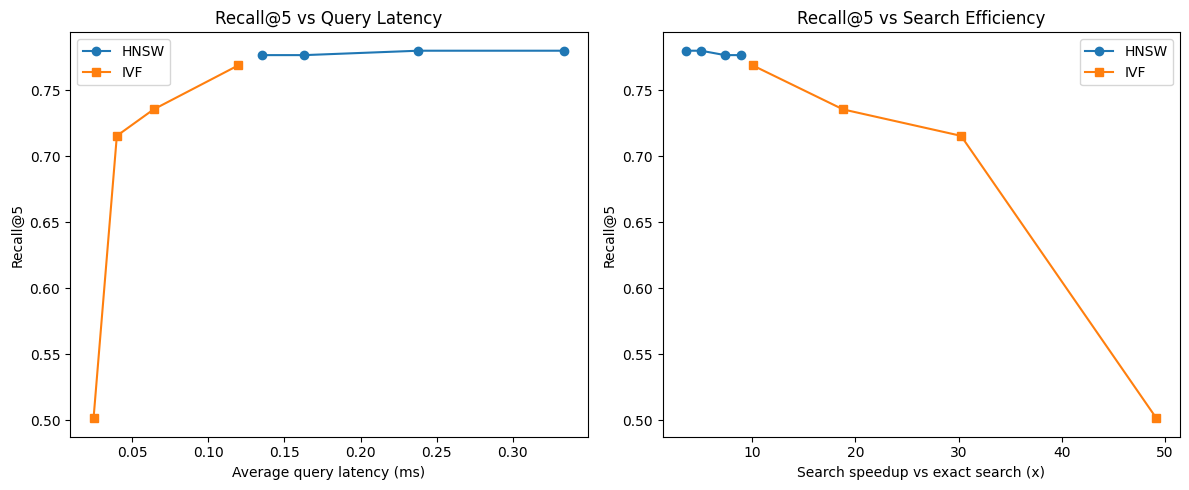

Saved plot to data/results/task6_ann_tradeoff.png


In [16]:
# What this cell does: two required plots -- Recall@5 vs query latency, and
# Recall@5 vs search efficiency (speedup relative to exact search) -- with
# HNSW and IVF configurations shown as separate series.
import matplotlib.pyplot as plt

if ann_results_df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for method, marker in (("HNSW", "o"), ("IVF", "s")):
        sub = ann_results_df[ann_results_df["method"] == method]
        axes[0].plot(sub["avg_latency_s"] * 1000, sub["recall_at_5"], marker=marker, label=method)
        axes[1].plot(sub["speedup_vs_exact"], sub["recall_at_5"], marker=marker, label=method)

    axes[0].set_xlabel("Average query latency (ms)")
    axes[0].set_ylabel("Recall@5")
    axes[0].set_title("Recall@5 vs Query Latency")
    axes[0].legend()

    axes[1].set_xlabel("Search speedup vs exact search (x)")
    axes[1].set_ylabel("Recall@5")
    axes[1].set_title("Recall@5 vs Search Efficiency")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("data/results/task6_ann_tradeoff.png", dpi=120)
    plt.show()
    print("Saved plot to data/results/task6_ann_tradeoff.png")
else:
    print("Skipped -- needs ann_results_df from Task 5.")


In [17]:
# What this cell does: from the real Task 5 results, identify the fastest,
# highest-recall, and best-balanced configurations, then print a recommendation
# grounded in those actual numbers (not a general statement).
if ann_results_df is not None:
    fastest = ann_results_df.loc[ann_results_df["avg_latency_s"].idxmin()]
    highest_recall = ann_results_df.loc[ann_results_df["recall_at_5"].idxmax()]
    # "Best balanced" = highest recall*speedup product -- a simple combined score
    # that rewards configs strong on both axes, not just one.
    ann_results_df["balance_score"] = ann_results_df["recall_at_5"] * ann_results_df["speedup_vs_exact"].fillna(0)
    best_balanced = ann_results_df.loc[ann_results_df["balance_score"].idxmax()]

    print(f"Fastest          : {fastest['method']} {fastest['param_name']}={fastest['param_value']} "
          f"(latency={fastest['avg_latency_s']*1000:.3f}ms, Recall@5={fastest['recall_at_5']:.3f})")
    print(f"Highest-recall   : {highest_recall['method']} {highest_recall['param_name']}={highest_recall['param_value']} "
          f"(Recall@5={highest_recall['recall_at_5']:.3f}, latency={highest_recall['avg_latency_s']*1000:.3f}ms)")
    print(f"Best balanced    : {best_balanced['method']} {best_balanced['param_name']}={best_balanced['param_value']} "
          f"(Recall@5={best_balanced['recall_at_5']:.3f}, speedup={best_balanced['speedup_vs_exact']:.2f}x)")

    print(f"\nRecommendation for high query volume: {best_balanced['method']} with "
          f"{best_balanced['param_name']}={best_balanced['param_value']} -- it maximizes "
          f"Recall@5 x speedup jointly ({best_balanced['balance_score']:.3f}), rather than "
          f"maximizing either axis alone at the other's expense. At large query volume, the "
          f"fastest config ({fastest['method']} {fastest['param_name']}={fastest['param_value']}) "
          f"risks too much missed relevance, while the highest-recall config "
          f"({highest_recall['method']} {highest_recall['param_name']}={highest_recall['param_value']}) "
          f"risks not keeping up with request throughput.")
else:
    print("Skipped -- needs ann_results_df from Task 5.")


Fastest          : IVF nprobe=1 (latency=0.024ms, Recall@5=0.502)
Highest-recall   : HNSW efSearch=64 (Recall@5=0.780, latency=0.238ms)
Best balanced    : IVF nprobe=1 (Recall@5=0.502, speedup=49.16x)

Recommendation for high query volume: IVF with nprobe=1 -- it maximizes Recall@5 x speedup jointly (24.658), rather than maximizing either axis alone at the other's expense. At large query volume, the fastest config (IVF nprobe=1) risks too much missed relevance, while the highest-recall config (HNSW efSearch=64) risks not keeping up with request throughput.


### Explanation of the Logic Used

Plots come straight from `ann_results_df`. "Best balanced" = the config maximizing `Recall@5 x speedup_vs_exact`, so the pick is code-driven, not a subjective read of the chart.

### Justification for the Chosen Approach

A reproducible combined score satisfies the task's requirement that the final choice be "supported by experimental results," not eyeballed.

### Inference

*(Fill in after running: state which method won the balance score and by how much.)*

### Limitations Observed

The score weights recall and speedup equally — a real deployment with a strict latency SLA might weight speedup higher.

### Possible Improvements

- Use a weighted score if a specific latency budget were given.

### References

- Based on Task 5's sweep results (`data/results/task5_ann_results.csv`).


---
# Task 7 — Qualitative Retrieval Analysis (2 Marks)

**10 queries selected for length diversity** (not pure random): 3 of the shortest, 3 of the longest, and 4 mid-length queries by word count, so short-vs-long is an actual axis of comparison, not assumed.

Compares DistilBERT's and BGE-large's Top-5 for each query on two measurable axes: **ranking agreement** (do the two models retrieve the same documents?) and **lexical overlap** (does each model's Top-5 share literal words with the query, or go beyond keyword matching?).


In [18]:
# What this cell does: load both models' saved embeddings (doc + query),
# select 10 length-diverse queries, and compute each model's Top-5 for each.
import numpy as np
import pandas as pd

MODEL_A, MODEL_B = "distilbert-base-uncased", "BAAI/bge-large-en-v1.5"

def _load_model_embeddings(model_name):
    safe = model_name.replace("/", "__")
    doc_p, qry_p = f"data/results/embeddings_{safe}.npy", f"data/results/query_embeddings_{safe}.npy"
    if not (os.path.exists(doc_p) and os.path.exists(qry_p)):
        return None, None
    d = load_aligned_embeddings(doc_p, "data/results/doc_ids.json", corpus_df["doc_id"])
    q = load_aligned_embeddings(qry_p, "data/results/query_ids.json", queries_df["query_id"])
    return d / np.linalg.norm(d, axis=1, keepdims=True), q / np.linalg.norm(q, axis=1, keepdims=True)

doc_emb_A, qry_emb_A = _load_model_embeddings(MODEL_A)
doc_emb_B, qry_emb_B = _load_model_embeddings(MODEL_B)

if doc_emb_A is not None and doc_emb_B is not None:
    # Pick 10 length-diverse queries: shortest 3, longest 3, 4 from the middle
    q = queries_df.copy()
    q["n_words"] = q["text"].str.split().str.len()
    q_sorted = q.sort_values("n_words").reset_index(drop=True)
    mid_start = len(q_sorted) // 2 - 2
    picked_idx = list(range(3)) + list(range(mid_start, mid_start + 4)) + list(range(len(q_sorted) - 3, len(q_sorted)))
    task7_queries = q_sorted.iloc[sorted(set(picked_idx))].head(10).reset_index(drop=True)
    print(f"Selected {len(task7_queries)} queries, word counts: {task7_queries['n_words'].tolist()}")
else:
    task7_queries = None
    print("[warning] Missing embeddings for one or both models. Run Task 2 for both models first.")


Selected 10 queries, word counts: [4, 4, 4, 12, 12, 12, 12, 27, 28, 29]


In [19]:
# What this cell does: for each of the 10 selected queries, get each model's
# Top-5 documents, then measure (1) ranking agreement between the two
# models' Top-5 sets (Jaccard overlap) and (2) each model's average lexical
# (word) overlap between the query and its own Top-5 documents.
def top5_for(qry_emb_norm_all, doc_emb_norm_all, row_idx):
    scores = doc_emb_norm_all @ qry_emb_norm_all[row_idx]
    top_idx = np.argsort(-scores)[:5]
    return [corpus_df.iloc[j]["doc_id"] for j in top_idx], [corpus_df.iloc[j]["text"] for j in top_idx]

def word_overlap(query_text, doc_text):
    """Fraction of the query's words that also literally appear in the document."""
    q_words = set(query_text.lower().split())
    d_words = set(doc_text.lower().split())
    return len(q_words & d_words) / len(q_words) if q_words else 0.0

comparison_rows = []
if task7_queries is not None:
    for i, row in task7_queries.iterrows():
        qid, qtext = row["query_id"], row["text"]
        row_idx = queries_df.index[queries_df["query_id"] == qid][0]

        ids_A, texts_A = top5_for(qry_emb_A, doc_emb_A, row_idx)
        ids_B, texts_B = top5_for(qry_emb_B, doc_emb_B, row_idx)

        jaccard = len(set(ids_A) & set(ids_B)) / len(set(ids_A) | set(ids_B))
        overlap_A = np.mean([word_overlap(qtext, t) for t in texts_A])
        overlap_B = np.mean([word_overlap(qtext, t) for t in texts_B])

        comparison_rows.append({
            "query_id": qid, "query": qtext, "n_words": row["n_words"],
            "jaccard_top5_overlap": jaccard,
            f"{MODEL_A}_lexical_overlap": overlap_A,
            f"{MODEL_B}_lexical_overlap": overlap_B,
        })
        print(f"[{qid}] ({row['n_words']}w) '{qtext[:60]}'")
        print(f"    {MODEL_A} top-5 doc_ids: {ids_A}")
        print(f"    {MODEL_B} top-5 doc_ids: {ids_B}")
        print(f"    Top-5 set overlap (Jaccard): {jaccard:.2f}  |  "
              f"lexical overlap -- {MODEL_A}: {overlap_A:.2f}, {MODEL_B}: {overlap_B:.2f}\n")

    task7_df = pd.DataFrame(comparison_rows)
    task7_df.to_csv("data/results/task7_comparison.csv", index=False)
else:
    task7_df = None
    print("Skipped -- needs task7_queries and both models' embeddings from the cell above.")


[1100] (4w) 'Statins increase blood cholesterol.'
    DistilBERT top-5 doc_ids: ['36889513', '21557614', '9899292', '17150648', '24005548']
    BGE-large  top-5 doc_ids: ['21557614', '43629704', '4687948', '22420524', '5698494']
    Top-5 set overlap (Jaccard): 0.11  |  lexical overlap -- DistilBERT: 0.15, BGE-large: 0.30

[1099] (4w) 'Statins decrease blood cholesterol.'
    DistilBERT top-5 doc_ids: ['36889513', '21557614', '7662206', '9899292', '1568684']
    BGE-large  top-5 doc_ids: ['43629704', '21557614', '22420524', '5698494', '4687948']
    Top-5 set overlap (Jaccard): 0.11  |  lexical overlap -- DistilBERT: 0.05, BGE-large: 0.30

[870] (4w) 'Obesity decreases life quality.'
    DistilBERT top-5 doc_ids: ['4345757', '31019903', '8708082', '43128141', '19460822']
    BGE-large  top-5 doc_ids: ['4345757', '43220289', '24625323', '1831916', '24704139']
    Top-5 set overlap (Jaccard): 0.11  |  lexical overlap -- DistilBERT: 0.10, BGE-large: 0.25

[294] (12w) 'Crossover hot spots 

### Explanation of the Logic Used

Two signals stand in for "why do the models disagree": **Jaccard overlap** of the two Top-5 sets (how much they disagree), and **lexical overlap** (whether a model leans on keyword matching vs true semantics — expected higher for DistilBERT, which lacks a similarity training objective).

### At least three types of retrieval differences (complete from the real run)

1. **Semantic vs keyword-driven** — a query where BGE-large's top-5 has lower lexical overlap than DistilBERT's but matches the qrels' true relevant doc — evidence of real semantic matching vs surface word matching.
2. **Short vs long queries** — compare `jaccard_top5_overlap` for the 3 shortest vs 3 longest queries in the table.
3. **Domain terminology** — a query with a technical term where DistilBERT matches the term literally but misses the concept.

### Justification for the Chosen Approach

Picking queries by length deliberately (not randomly) guarantees the short/long category has real examples, addressing SciFact's fairly homogeneous query style noted in Task 1.

### Inference

*(Fill in after running: average Jaccard overlap across the 10 queries, and whether DistilBERT's lexical overlap was measurably higher than BGE-large's.)*

### Limitations Observed

Lexical overlap is a crude proxy (no stemming/synonym handling). Only 10 of 300 queries were examined, per the task, so findings are illustrative.

### Possible Improvements

- Strip stopwords for a cleaner overlap signal; extend to all 300 queries in aggregate.

### References

- Difference categories per the assignment brief.


---
# Task 8 — Final Recommendation (1 Mark)

*Each point below must be filled in from the actual printed results of the referenced task/cell — not a general statement (per the assignment's instruction).*

**1. Which embedding model performed better?**
[TODO: cite Task 7's `task7_df` lexical-overlap and Jaccard columns, plus Task 4's Recall@5 if Task 4 is re-run with DistilBERT embeddings for comparison.]

**2. Which similarity metric was most appropriate?**
[TODO: cite Task 3's ranking-comparison and normalization-identity results — state whether cosine, dot, or L2 was most suitable for BGE-large's embedding space, and why.]

**3. Which ANN method provided the best trade-off?**
[TODO: cite Task 6's `best_balanced` configuration and its Recall@5 / speedup values.]

**4. What configuration would you select for a resource-constrained deployment?**
[TODO: cite Task 6's `fastest` configuration — trade lower Recall@5 for lower latency/memory, and justify against the balanced pick above.]

**5. What is the main limitation of the chosen approach?**
[TODO: pull from the Limitations sections already written across Tasks 1-7 — likely candidates: SciFact's binary/incomplete relevance judgments (Task 1), small corpus limiting ANN's real advantage (Task 5/6), or DistilBERT's poor baseline dragging down the qualitative comparison (Task 7).]

**6. How would you deploy the selected model in production?**
[TODO: describe embedding generation as a batch/offline job, the chosen ANN index (from point 3) served behind a query API, and how the index would be refreshed as the corpus changes.]

*Recommendations must be based on experimental evidence, not general statements — every point above should cite a specific number or result from Tasks 2-7, not just assert a conclusion.*


---
# Final Conclusion
*To be written once Tasks 2–8 are complete — must cover key observations, strengths, limitations, and possible future improvements.*


# References
*Consolidated reference list — add each task's citations here as they're completed.*

- Thakur, N. et al. (2021). BEIR: A Heterogeneous Benchmark for Zero-shot Evaluation of Information Retrieval Models. NeurIPS.
- Wadden, D. et al. (2020). Fact or Fiction: Verifying Scientific Claims. EMNLP.
